In [1]:
# imports

import pickle
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import pandas as pd
import warnings
import math

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

from collections import Counter


warnings.filterwarnings('ignore')

In [2]:
# load data

with open ('WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

wrist = data['signal']['wrist']
print(data.keys())
print(wrist.keys())

dict_keys(['signal', 'label', 'subject'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


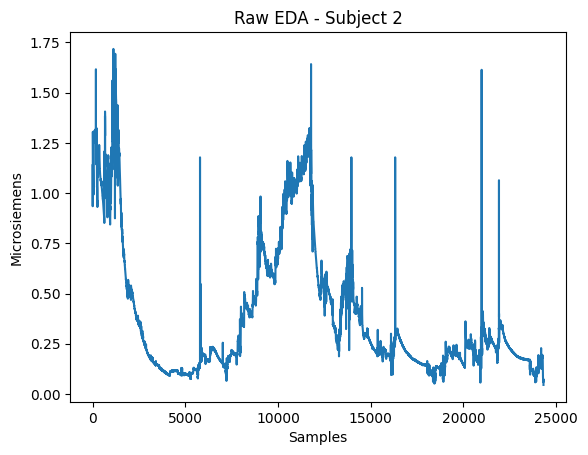

In [3]:
# process the raw EDA + plot

EDA_RATE = 4
LABEL_RATE = 700

eda_raw = wrist['EDA'].flatten()
eda_signals, eda_info = nk.eda_process(eda_raw, sampling_rate=EDA_RATE)
labels = data['label'].flatten()
plt.plot(eda_raw)
plt.title('Raw EDA - Subject 2')
plt.xlabel('Samples')
plt.ylabel('Microsiemens')
plt.show()

BVP samples: 389056
BVP duration: 6079.0 seconds
PPG columns: ['PPG_Raw', 'PPG_Clean', 'PPG_Rate', 'PPG_Quality', 'PPG_Peaks']

ACC shape: (194528, 3)
ACC Duration: 6079.0 seconds


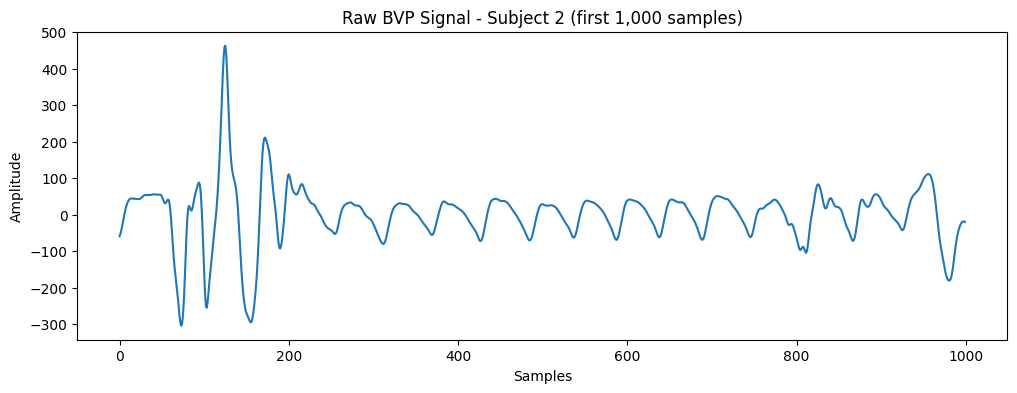

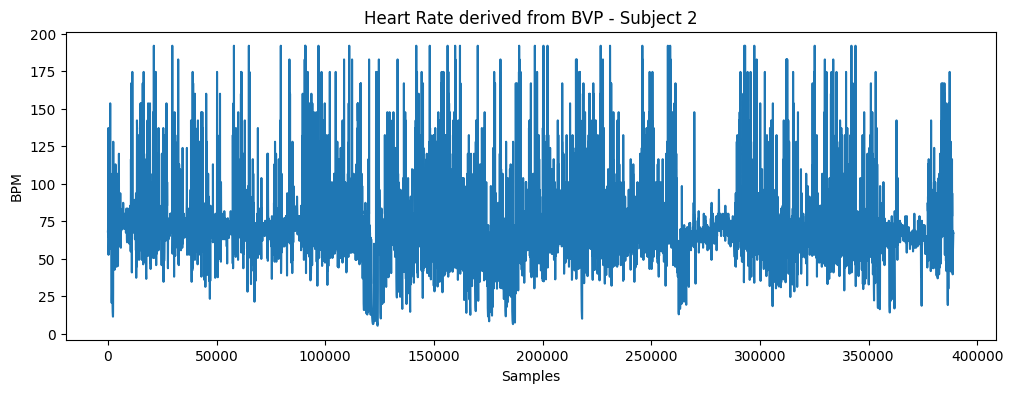

In [4]:
# process BVP (blood volume pulse) and load accelerometer
# runs alongside EDA

BVP_RATE = 64
ACC_RATE = 32

bvp_raw = wrist['BVP'].flatten()
ppg_signals, ppg_info = nk.ppg_process(bvp_raw, sampling_rate=BVP_RATE)

print(f"BVP samples: {len(bvp_raw)}")
print(f"BVP duration: {len(bvp_raw)/BVP_RATE:.1f} seconds")
print(f"PPG columns: {list(ppg_signals.columns)}")

# load the accelerometer data
acc_raw = wrist['ACC']
print(f"\nACC shape: {acc_raw.shape}")
print(f"ACC Duration: {len(acc_raw)/ACC_RATE:.1f} seconds")

# plot of BVPf
plt.figure(figsize=(12, 4))
plt.plot(bvp_raw[:1000])
plt.title('Raw BVP Signal - Subject 2 (first 1,000 samples)')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

# plot of Heart rate from BVP
hr_values = ppg_signals['PPG_Rate'].dropna()
plt.figure(figsize=(12, 4))
plt.plot(hr_values.values)
plt.title('Heart Rate derived from BVP - Subject 2')
plt.xlabel('Samples')
plt.ylabel('BPM')
plt.show()

In [5]:
# downsample -- basically GCF
label_downsample_factor = LABEL_RATE // EDA_RATE

# takes every 175th label in order to make it the same size as the EDA data
labels_eda = labels[::label_downsample_factor]

# trim the label array so the two arrays are aligned
eda_length = len(wrist['EDA'].flatten())
labels_eda = labels_eda[:eda_length]

print(f"EDA samples: {eda_length}")
print(f"Downsampled labels: {len(labels_eda)}")


eda_signals['Label'] = labels_eda
print("Label column added successfully")
print(eda_signals['Label'].value_counts())

EDA samples: 24316
Downsampled labels: 24316
Label column added successfully
Label
0    12244
1     4576
4     3072
2     2460
3     1448
6      260
7      256
Name: count, dtype: int64


In [6]:
# ensure that dataframe only includes two labels -- 1, which is baseline, and 2, which is stress -- the actual model will probably just be baseline to compare but idk
eda_signals = eda_signals[eda_signals['Label'].isin([1, 2])].copy()

# turns baseline from 1 and 2 to 0 and 1 (since 2 -> True -> 1, and 1 -> False -> 0)
eda_signals['Label'] = (eda_signals['Label'] == 2).astype(int)
print(f"Baseline samples: {(eda_signals['Label'] == 0).sum()}")
print(f"Stress samples: {(eda_signals['Label'] == 1).sum()}")

Baseline samples: 4576
Stress samples: 2460


In [9]:
def extract_features_from_window(window_eda,
                                window_bvp=None,
                                window_acc=None):

    """
    Extract features from EDA, and maybe BVP and ACC
    window_eda: processed EDA DataFrame
    window_bvp: processed PPG DataFrame
    window_acc: shape of the raw accelerometer array
    """
    features = {}

    # -- Tonic --
    tonic = window_eda['EDA_Tonic'].values

    # calculates statistics
    features['tonic_mean'] = np.mean(tonic)
    features['tonic_std'] = np.std(tonic)
    features['tonic_min'] = np.min(tonic)
    features['tonic_max'] = np.max(tonic)
    features['tonic_slope'] = np.polyfit(
        np.arange(len(tonic)), tonic, 1)[0]

    # Relative tonic features
    features['tonic_range'] = np.max(tonic) - np.min(tonic)

    # find the drift of the baseline -- !!!!!!!!!!!!!!!!!!!!!
    features['tonic.cv'] = (
        np.std(tonic) / np.mean(tonic)
        if np.mean(tonic) > 0 else 0
    )
    
    # -- Phasic --
    phasic = window_eda['EDA_Phasic'].values

    # calculates statistics
    features['phasic_mean'] = np.mean(phasic)
    features['phasic_std'] = np.std(phasic)
    features['phasic_min'] = np.min(phasic)
    features['phasic_max'] = np.max(phasic)

    # relative phasic features
    features['phasic_range'] = np.max(phasic) - np.min(phasic)

    # -- SCR peak --
    scr_peaks = window_eda['SCR_Peaks'].values # 1 at peaks, 0 elsewhere
    features['scr_count'] = np.sum(scr_peaks) # gets the total # of peaks
    
    peak_amplitudes = window_eda.loc[
        window_eda['SCR_Peaks'] == 1, 'SCR_Amplitude'].values # gives an array of amplitudes for all detected peaks (window.loc[condition, column])

    # mean amplitude... it says it right there.
    features['scr_mean_amplitude'] = (
        np.mean(peak_amplitudes) if len(peak_amplitudes) > 0 else 0
    )

    # time it took for the EDA to rise and recover away from / back to baseline
    features['scr_mean_rise_time'] = (
        np.mean(window_eda.loc[
            window_eda['SCR_Peaks'] == 1, 'SCR_RiseTime'
            ].values) if len(peak_amplitudes) > 0 else 0
    )

    features['scr_mean_recovery_time'] = (
        np.mean(window_eda.loc[
            window_eda['SCR_Peaks'] == 1, 'SCR_RecoveryTime'].values) if len(peak_amplitudes) > 0 else 0
    )

    # -- BVP / HRV --

    if window_bvp is not None:

        # Heart rate statistics
        hr_values = window_bvp['PPG_Rate'].values
        hr_clean = hr_values[~np.isnan(hr_values)] #Removes NaN values

        # captures how much heart rate varied in this window
        # high variation -> arousal state change
        if len(hr_clean) > 0:
            features['hr_mean'] = np.mean(hr_clean)
            features['hr_std'] = np.std(hr_clean)
            features['hr_min'] = np.min(hr_clean)
            features['hr_max'] = np.max(hr_clean)
            features['hr_range'] = (
                np.max(hr_clean) - np.min(hr_clean)
            )

        else:
            for key in ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range']:
                features[key] = 0

        # HRV features from interbeat intervals
        # np.where returns the indices where the condition is True and [0] gets the array
        peak_locs = np.where(
            window_bvp['PPG_Peaks'].values == 1
        )[0]

        if len(peak_locs) > 2:
            # there have to be three peaks for meaningful data
            # converts ms per sample to ms
            ibi_ms = np.diff(peak_locs) * (1000.0 / BVP_RATE)

            # root mean square
            # higher = parasympathetic
            # lower = more sympathetic
            features['hrv_rmssd'] = np.sqrt(
                np.mean(np.diff(ibi_ms) ** 2)
            )

            # std of IBI -- overall variability across each window
            features['hrv_sdnn'] = np.std(ibi_ms)

            # avg time between beats
            features['hrv_mean_ibi'] = np.mean(ibi_ms)

            # coeff of variation
            features['hrv_cv'] = (
                np.std(ibi_ms) / np.mean(ibi_ms)
                if np.mean(ibi_ms) > 0 else 0
            )

        else:
            for key in ['hrv_rmssd', 'hrv_sdnn', 'hrv_mean_ibi', 'hrv_cv']:
                features[key] = 0

        # EDA-Cardiac cross-signal feature
        # PAMG-AT (Yildiz & Subasi, 2026)
        # said ECG-EDA relationships were the most predictive of stress in wrist sensors

        hr_values = window_bvp['PPG_Rate'].values
        tonic_values = window_eda['EDA_Tonic'].values

        # resample to same length for correlation
        min_len = min(len(hr_values), len(tonic_values))
        hr_trimmed = hr_values[:min_len]
        tonic_trimmed = tonic_values[:min_len]

        # remove NaN
        valid_mask = ~np.isnan(hr_trimmed)

        # positive: EDA + HR rise together
        # negative: one rises, one falls
        # near zero: no correlation
        if np.sum(valid_mask) > 10:
            features['eda_hr_correlation'] = np.corrcoef(tonic_trimmed[valid_mask],
                                                         hr_trimmed[valid_mask]
                                                        )[0, 1]
        else:
            features['eda_hr_correlation'] = 0
            
    # -- Accelerometer! --

    if window_acc is not None:
        # compute vector magnitude w/ X, Y, Z
        acc_magnitude = np.sqrt(
            window_acc[:, 0]**2 +
            window_acc[:, 1]**2 +
            window_acc[:, 2]**2
        )

        # average movement intensity
        features['acc_mean'] = np.mean(acc_magnitude)

        # movement variability (higher std = more fidgety)
        features['acc_std'] = np.std(acc_magnitude)

        # peak movement
        features['acc_max'] = np.max(acc_magnitude)

        # movement range
        features['acc_above_threshold'] = np.mean(
            acc_magnitude > np.mean(acc_magnitude) + np.std(acc_magnitude)
        )

        
    return features

print("Function defined")

Function defined


In [10]:
WINDOW_SIZE = 60
STEP_SIZE = 30

SAMPLES_PER_WINDOW_EDA = WINDOW_SIZE * EDA_RATE
SAMPLES_PER_STEP_EDA = STEP_SIZE * EDA_RATE

SAMPLES_PER_WINDOW_BVP = WINDOW_SIZE * BVP_RATE
SAMPLES_PER_STEP_BVP = STEP_SIZE * BVP_RATE

SAMPLES_PER_WINDOW_ACC = WINDOW_SIZE * ACC_RATE
SAMPLES_PER_STEP_ACC = STEP_SIZE * ACC_RATE

BVP_RATIO = BVP_RATE // EDA_RATE
ACC_RATIO = ACC_RATE // EDA_RATE

feature_rows = []
label_rows = []

# resets the dataframe index to 0, since values that weren't labeled 1 and 2 were dropped
eda_signals = eda_signals.reset_index(drop=True)

start_eda = 0
windows_skipped = 0
windows_extracted = 0

while start_eda + SAMPLES_PER_WINDOW_EDA <= len(eda_signals):
    end_eda = start_eda + SAMPLES_PER_WINDOW_EDA
    window_eda = eda_signals.iloc[start_eda:end_eda]

    window_labels = window_eda['Label'].values

    # if there is more than one label in the window, it gets skipped because it has both stressed and baseline data and doesn't extract
    if len(np.unique(window_labels)) > 1:
        windows_skipped += 1
        start_eda += SAMPLES_PER_STEP_EDA
        continue

    # calculate the corrosponding positions in BVP and ACC -- EDA position * ratio
    start_bvp = start_eda * BVP_RATIO
    end_bvp = start_bvp + SAMPLES_PER_WINDOW_BVP

    start_acc = start_eda * ACC_RATIO
    end_acc = start_acc + SAMPLES_PER_WINDOW_ACC

    # check if the BVP and ACC windows are in bound
    if end_bvp > len(ppg_signals) or end_acc > len(acc_raw):
        start_eda += SAMPLES_PER_STEP_EDA
        continue
        
    window_bvp = ppg_signals.iloc[start_bvp:end_bvp]
    window_acc = acc_raw[start_acc:end_acc]
    
    # extracts features from the window... duh
    # and then adds a new row to the feature_rows array
    features = extract_features_from_window(window_eda, window_bvp, window_acc)
    feature_rows.append(features)
    label_rows.append(window_labels[0])
    windows_extracted += 1
    
    start_eda += SAMPLES_PER_STEP_EDA

# converts the list of dictionaries (i.e. feature_rows) into a DataFrame with each dictionary being a row and the key being the column 
# feature_df and label_array is the training data
feature_df = pd.DataFrame(feature_rows)
label_array = np.array(label_rows)

print(f"Windows extracted: {windows_extracted}")
print(f"Windows skipped (boundary): {windows_skipped}")
print(f"Features per window: {len(feature_df.columns)}")
print(f"Baseline windows: {np.sum(label_array == 0)}")
print(f"Stress windows: {np.sum(label_array == 1)}")
print(f"\nFeature names:")
for i, name in enumerate(feature_df.columns):
    print(f" {i+1:2d}. {name}")

Windows extracted: 55
Windows skipped (boundary): 2
Features per window: 30
Baseline windows: 37
Stress windows: 18

Feature names:
  1. tonic_mean
  2. tonic_std
  3. tonic_min
  4. tonic_max
  5. tonic_slope
  6. tonic_range
  7. tonic.cv
  8. phasic_mean
  9. phasic_std
 10. phasic_min
 11. phasic_max
 12. phasic_range
 13. scr_count
 14. scr_mean_amplitude
 15. scr_mean_rise_time
 16. scr_mean_recovery_time
 17. hr_mean
 18. hr_std
 19. hr_min
 20. hr_max
 21. hr_range
 22. hrv_rmssd
 23. hrv_sdnn
 24. hrv_mean_ibi
 25. hrv_cv
 26. eda_hr_correlation
 27. acc_mean
 28. acc_std
 29. acc_max
 30. acc_above_threshold


In [11]:
# checks for NaN values in each column and fills all of them with 0
print("Missing values per feature:")
print(feature_df.isnull().sum())

feature_df = feature_df.fillna(0)
print("\nAfter filling, missing values are:")
print(feature_df.isnull().sum().sum())

Missing values per feature:
tonic_mean                0
tonic_std                 0
tonic_min                 0
tonic_max                 0
tonic_slope               0
tonic_range               0
tonic.cv                  0
phasic_mean               0
phasic_std                0
phasic_min                0
phasic_max                0
phasic_range              0
scr_count                 0
scr_mean_amplitude        0
scr_mean_rise_time        0
scr_mean_recovery_time    0
hr_mean                   0
hr_std                    0
hr_min                    0
hr_max                    0
hr_range                  0
hrv_rmssd                 0
hrv_sdnn                  0
hrv_mean_ibi              0
hrv_cv                    0
eda_hr_correlation        0
acc_mean                  0
acc_std                   0
acc_max                   0
acc_above_threshold       0
dtype: int64

After filling, missing values are:
0


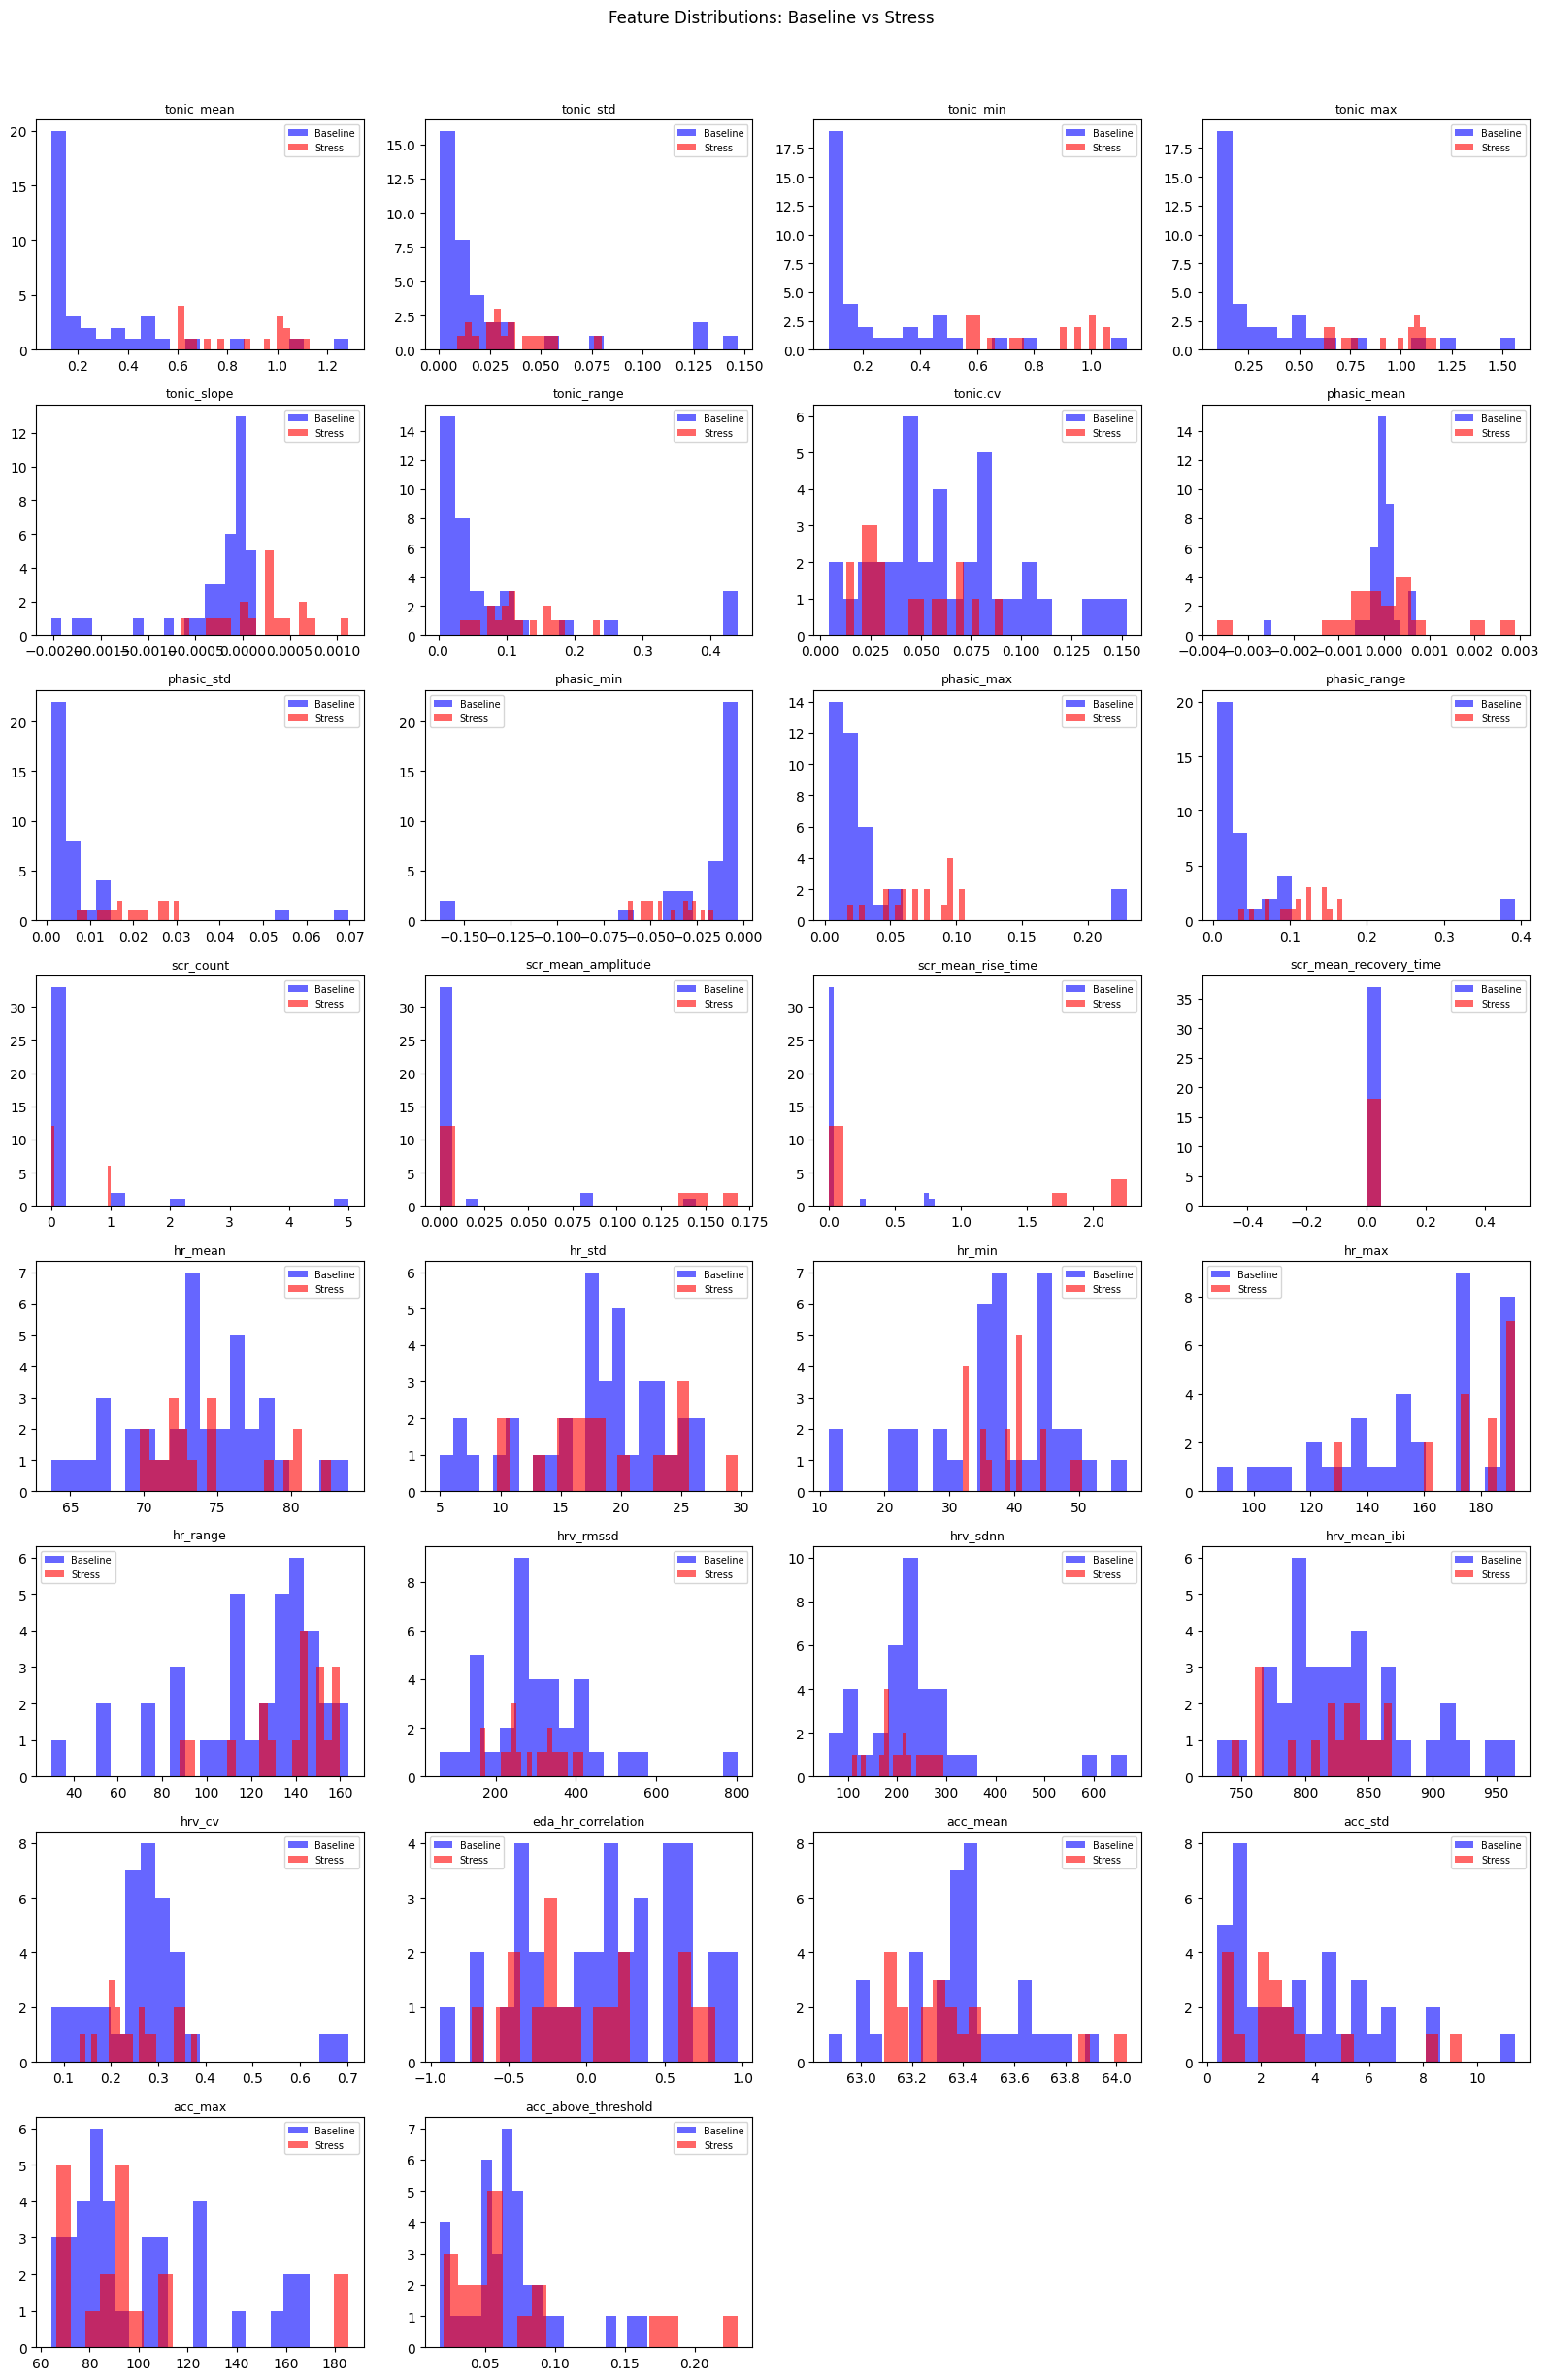

In [12]:
# gets list of column names and counts them
feature_names = list(feature_df.columns)
n_features = len(feature_names)

# calculate grid dimensions
n_cols= 4
n_rows = math.ceil(n_features / n_cols)

# create figure with grid of subplots -- fig is the figure object with axes being a 2D array
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3)) # the width is 16 by 3*number of rows
axes = axes.flatten()

feature_names = list(feature_df.columns)

for i, feature_name in enumerate(feature_names):
    ax = axes[i]

    # selects feature values for each class -- False or 0 = baseline, True or 1 = stress, 
    baseline_vals = feature_df[feature_name][label_array == 0]
    stress_vals = feature_df[feature_name][label_array == 1]

    # draws histograms
    ax.hist(baseline_vals, alpha=0.6, label='Baseline', color='blue', bins=20)
    ax.hist(stress_vals, alpha=0.6, label='Stress', color='red', bins=20)
    ax.set_title(feature_name, fontsize=9)
    ax.legend(fontsize=7)

# hide unused subpolots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Baseline vs Stress', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# X is the DataFrame as a numpy array, and y is the array of labels since scikit expects numpy arrays
X = feature_df.values
y = label_array

scaler = StandardScaler() # gets the z value -- ap stats throwback so awesome
X_scaled = scaler.fit_transform(X) # applies it to X.fit_transform

# train on the full dataset -- mostly just a sanity check 
# n_estimators -> the number of individual decision trees.
# random_state -> random seed to ensure you get idnetical results. 42 is arbitrary tho.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_scaled, y)

y_pred = clf.predict(X_scaled)
print(f"In-sample accuracy: {accuracy_score(y, y_pred):.3f}")
# expect to be high -- it's not real accuracy, it just confirms that it works

In-sample accuracy: 1.000


Feature importances:
               feature  importance
            tonic_mean    0.214862
             tonic_min    0.167143
             tonic_max    0.127044
            phasic_std    0.061376
            phasic_max    0.057965
           tonic_slope    0.054409
          phasic_range    0.050439
             tonic_std    0.038167
              tonic.cv    0.038106
            phasic_min    0.035632
           tonic_range    0.023757
                hr_max    0.016700
               acc_max    0.012232
               acc_std    0.010655
             hrv_rmssd    0.010492
    scr_mean_rise_time    0.010036
              hr_range    0.009063
                hrv_cv    0.007694
    eda_hr_correlation    0.006587
          hrv_mean_ibi    0.006493
           phasic_mean    0.006112
                hr_std    0.005771
              acc_mean    0.005591
             scr_count    0.005262
                hr_min    0.005054
   acc_above_threshold    0.004509
               hr_mean    0.004370

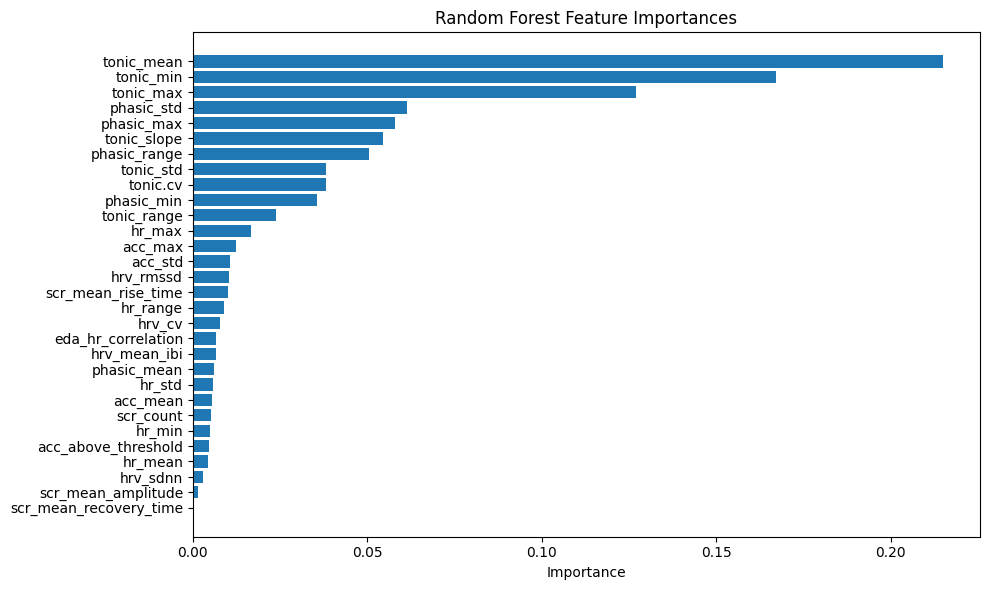

In [14]:
# Goal: look at the features that the model finds the most useful

importances = clf.feature_importances_
# higher num = more useful classification

# sorts the feature importances in descending order
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature importances:")
print(importance_df.to_string(index=False))

# plot
# horizontal bars
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# leave one subject out (LOSO) with one subject as a placeholder

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
# stratified = same class ratio in train and testing
# 5 splits = 5 different random train / test cuts
# test size means 20% of data is tested at a time

fold_accuracies = []

# sss.split -> generates pairs of index arrays
# train_idx -> row indices for training
# test_idx -> row indices for testing
for fold, (train_idx, test_idx) in enumerate(sss.split(X, y)):
    
    # uses index arrays to split features / labels into separate training and testing sets
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # fit scaler on ONLY training data
    scaler_fold = StandardScaler()
    X_train_scaled = scaler_fold.fit_transform(X_train) # mean / std from training only
    X_test_scaled = scaler_fold.transform(X_test) # applies the same training statistics

    # trains a new classifier
    clf_fold = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_fold.fit(X_train_scaled, y_train)

    # does a prediction on test data, computes accuracy, stores, prints it
    y_pred = clf_fold.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} accuracy: {acc:.3f}")

# prints
print(f"\nMean accuracy: {np.mean(fold_accuracies):.3f}")
print(f"Std: {np.std(fold_accuracies):.3f}")
print(f"\nDetailed report (last fold):")
print(classification_report(y_test, y_pred, 
      target_names=['Baseline', 'Stress']))

Fold 1 accuracy: 1.000
Fold 2 accuracy: 0.818
Fold 3 accuracy: 1.000
Fold 4 accuracy: 0.909
Fold 5 accuracy: 1.000

Mean accuracy: 0.945
Std: 0.073

Detailed report (last fold):
              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00         7
      Stress       1.00      1.00      1.00         4

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [16]:
def process_subject(subject_id):
    """
    Loads and processes one subject
    Extracts EDA, BVP, ACC features
    Returns feature DataFrame, labels, and subject ID array
    """
    path = f'WESAD/S{subject_id}/S{subject_id}.pkl'
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist = data['signal']['wrist']
    labels = data['label'].flatten()

    #process EDA
    eda_raw = wrist['EDA'].flatten()
    eda_sig, _ = nk.eda_process(eda_raw, sampling_rate=EDA_RATE)

    # process bvp
    bvp_raw = wrist['BVP'].flatten()
    ppg_sig, _ = nk.ppg_process(bvp_raw, sampling_rate=BVP_RATE)

    # "process" acc (it's already a 2D array)
    acc = wrist['ACC']
    
    # downsample and align labels to EDA rate
    labels_eda = labels[::label_downsample_factor]
    labels_eda = labels_eda[:len(eda_sig)]
    eda_sig['Label'] = labels_eda

    # filter to baseline and stress only + remap to 0 and 1 (like cell 5)
    eda_sig = eda_sig[
        eda_sig['Label'].isin([1, 2])
    ].copy().reset_index(drop=True)
    eda_sig['Label'] = (eda_sig['Label'] == 2).astype(int)

    # extract windows
    feature_rows = []
    label_rows = []
    start_eda = 0

    while start_eda + SAMPLES_PER_WINDOW_EDA <= len(eda_sig):
        end_eda = start_eda + SAMPLES_PER_WINDOW_EDA
        window_eda = eda_sig.iloc[start_eda:end_eda]
        window_labels = window_eda['Label'].values

        if len(np.unique(window_labels)) > 1:
            start_eda += SAMPLES_PER_STEP_EDA
            continue

        # align BVP and ACC windows
        start_bvp = start_eda * BVP_RATIO
        end_bvp = start_bvp + SAMPLES_PER_WINDOW_BVP
        start_acc = start_eda * ACC_RATIO
        end_acc = start_acc + SAMPLES_PER_WINDOW_ACC

        if end_bvp > len(ppg_sig) or end_acc > len(acc):
            start_eda += SAMPLES_PER_STEP_EDA
            continue

        window_bvp = ppg_sig.iloc[start_bvp:end_bvp]
        window_acc = acc[start_acc:end_acc]

        features = extract_features_from_window(window_eda, window_bvp, window_acc)
        feature_rows.append(features)
        label_rows.append(window_labels[0])
        start_eda += SAMPLES_PER_STEP_EDA

    # builds dataframe -- np.full makes an array entirely out of the subject's id number so every window from subject 3 has a 3 in subject_arr
    # so that LOSO can know which windows belong to which subjects
    features_df = pd.DataFrame(feature_rows).fillna(0)
    labels_arr = np.array(label_rows)
    subject_arr = np.full(len(labels_arr), subject_id)

    return features_df, labels_arr, subject_arr


# test with all subjects. there are 17 total subjects, but subject 1 was excluded in the original study
all_features = []
all_labels = []
all_subjects = []

for sid in range (2, 18):
    # try and except is because subject 12 isn't in the original dataset
    try:
        print(f"Processing subject {sid}...")
        f, l, s = process_subject(sid)
        all_features.append(f)
        all_labels.append(l)
        all_subjects.append(s)
        print(f" Windows extracted: {len(f)} | "
              f"Baseline: {np.sum(l==0)} | "
              f"Stress: {np.sum(l==1)}")
    except FileNotFoundError:
        print(f" Subject {sid} not found, skipping.")
    except Exception as e:
        print(f" Subject {sid} error: {e}, skipping")

X_unscaled = np.vstack([f.values for f in all_features])
y_all = np.concatenate(all_labels)
groups_all = np.concatenate(all_subjects)

print(f"\nTotal windows across all subjects: {len(X_unscaled)}")
print(f"Total features: {X_unscaled.shape[1]}")
print(f"Baseline: {np.sum(y_all == 0)}")
print(f"Stress: {np.sum(y_all == 1)}")
print(f"Subjects loaded: {np.unique(groups_all)}")

Processing subject 2...
 Windows extracted: 55 | Baseline: 37 | Stress: 18
Processing subject 3...
 Windows extracted: 57 | Baseline: 37 | Stress: 20
Processing subject 4...
 Windows extracted: 56 | Baseline: 37 | Stress: 19
Processing subject 5...
 Windows extracted: 58 | Baseline: 38 | Stress: 20
Processing subject 6...
 Windows extracted: 58 | Baseline: 38 | Stress: 20
Processing subject 7...
 Windows extracted: 57 | Baseline: 38 | Stress: 19
Processing subject 8...
 Windows extracted: 58 | Baseline: 37 | Stress: 21
Processing subject 9...
 Windows extracted: 57 | Baseline: 38 | Stress: 19
Processing subject 10...
 Windows extracted: 60 | Baseline: 38 | Stress: 22
Processing subject 11...
 Windows extracted: 59 | Baseline: 38 | Stress: 21
Processing subject 12...
 Subject 12 not found, skipping.
Processing subject 13...
 Windows extracted: 58 | Baseline: 38 | Stress: 20
Processing subject 14...
 Windows extracted: 58 | Baseline: 38 | Stress: 20
Processing subject 15...
 Windows extr

In [17]:
# real LOSO with all subjects

logo = LeaveOneGroupOut()
loso_accuracies = []
loso_balanced_accuracies = []
subject_ids_tested = []

for train_idx, test_idx in logo.split(X_unscaled, y_all, groups=groups_all):

    # splits into training + testing data based on index arrays
    X_train, X_test = X_unscaled[train_idx], X_unscaled[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]


    # get the subject tested on this fold
    test_subject = groups_all[test_idx[0]]

    # scales inside the fold like in cell 12
    scaler_loso = StandardScaler()
    X_train_scaled = scaler_loso.fit_transform(X_train)
    X_test_scaled = scaler_loso.transform(X_test)

    # trains a new classifier on all subjects
    clf_loso = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_loso.fit(X_train_scaled, y_train)
    y_pred = clf_loso.predict(X_test_scaled)
    
    # computes the raw and balanced accuracy, stores and prints summary
    acc = accuracy_score(y_test, y_pred)
    loso_accuracies.append(acc)
    subject_ids_tested.append(test_subject)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    loso_balanced_accuracies.append(bal_acc)
    print(f"Subject {test_subject} | "
          f"Accuracy: {acc:.3f} | "
          f"Balanced: {bal_acc:.3f} | "
          f"n={len(test_idx)}")

print(f"\nMean LOSO accuracy: {np.mean(loso_accuracies):.3f}")
print(f"Std: {np.std(loso_accuracies):.3f}")
print(f"Min: {np.min(loso_accuracies):.3f}")
print(f"Max: {np.max(loso_accuracies):.3f}")

print(f"Mean balanced accuracy: "
      f"{np.mean(loso_balanced_accuracies):.3f}")

Subject 2 | Accuracy: 0.764 | Balanced: 0.653 | n=55
Subject 3 | Accuracy: 0.772 | Balanced: 0.686 | n=57
Subject 4 | Accuracy: 1.000 | Balanced: 1.000 | n=56
Subject 5 | Accuracy: 0.638 | Balanced: 0.688 | n=58
Subject 6 | Accuracy: 0.845 | Balanced: 0.811 | n=58
Subject 7 | Accuracy: 0.807 | Balanced: 0.855 | n=57
Subject 8 | Accuracy: 0.931 | Balanced: 0.905 | n=58
Subject 9 | Accuracy: 0.772 | Balanced: 0.658 | n=57
Subject 10 | Accuracy: 0.533 | Balanced: 0.526 | n=60
Subject 11 | Accuracy: 0.763 | Balanced: 0.805 | n=59
Subject 13 | Accuracy: 0.759 | Balanced: 0.816 | n=58
Subject 14 | Accuracy: 0.655 | Balanced: 0.500 | n=58
Subject 15 | Accuracy: 1.000 | Balanced: 1.000 | n=59
Subject 16 | Accuracy: 0.914 | Balanced: 0.875 | n=58
Subject 17 | Accuracy: 0.783 | Balanced: 0.743 | n=60

Mean LOSO accuracy: 0.796
Std: 0.126
Min: 0.533
Max: 1.000
Mean balanced accuracy: 0.768


In [18]:
# check for imbalances cuz subjects 4 and 15 had 100 accuracy 
for sid in [4, 15]:
    mask = groups_all == sid
    baseline = np.sum(y_all[mask] == 0)
    stress = np.sum(y_all[mask] == 1)
    total = baseline + stress
    print(f"Subject {sid}: {baseline} baseline, "
          f"{stress} stress, "
          f"majority class = {max(baseline,stress)/total:.1%}")

Subject 4: 37 baseline, 19 stress, majority class = 66.1%
Subject 15: 38 baseline, 21 stress, majority class = 64.4%


In [19]:
# find the optimal number of features

k_values = [5, 8, 10, 13, 15, 18, 20, 23, 25, 29] # 13 and 29 are anchor values -- everything else is just equally distributed
k_results = {}

for k in k_values:
    fold_scores = []
    fold_raw_scores = []

    for train_idx, test_idx in logo.split(
        X_unscaled, y_all, groups=groups_all
    ):
        X_train = X_unscaled[train_idx]
        X_test = X_unscaled[test_idx]
        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        # fit selection based on only training data (no leakage)
        # finds the highest K values
        selector = SelectKBest(f_classif, k=k)
        X_train_sel = selector.fit_transform(X_train, y_train)
        X_test_sel = selector.transform(X_test)

        # 
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train_sel)
        X_test_s = scaler.transform(X_test_sel)

        clf = RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42
        )
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        fold_scores.append(
            balanced_accuracy_score(y_test, y_pred)
        )
        fold_raw_scores.append(
            accuracy_score(y_test, y_pred)
        )

    k_results[k] = {
        'mean': np.mean(fold_scores),
        'std': np.std(fold_scores),
        'raw mean': np.mean(fold_raw_scores)
    }

    print(f"K = {k:2d} | "
          f"Balanced accuracy: {np.mean(fold_scores):.3f} "
          f"(+/-{np.std(fold_scores):.3f}) "
          f"Raw: {np.mean(fold_raw_scores):.3f}")

best_k = max(k_results, key=lambda k: k_results[k]['mean']) # finds the best K... duh.
print(f"\nBest K: {best_k}")
print(f"Best balanced accuracy: {k_results[best_k]['mean']:.3f}")
print(f"Best raw accuracy: {k_results[best_k]['raw mean']:.3f}")
print(f"\nK=13 balanced: {k_results[13]['mean']:.3f} | "
      f"raw: {k_results[13]['raw mean']:.3f}")
print(f"K=29 balanced: {k_results[29]['mean']:.3f} | "
     f"raw: {k_results[29]['raw mean']:.3f}")
print(f"EDA-only (K=13): {k_results[13]['mean']:.3f}")

K =  5 | Balanced accuracy: 0.741 (+/-0.176) Raw: 0.779
K =  8 | Balanced accuracy: 0.799 (+/-0.132) Raw: 0.825
K = 10 | Balanced accuracy: 0.780 (+/-0.155) Raw: 0.806
K = 13 | Balanced accuracy: 0.820 (+/-0.127) Raw: 0.843
K = 15 | Balanced accuracy: 0.817 (+/-0.129) Raw: 0.843
K = 18 | Balanced accuracy: 0.805 (+/-0.129) Raw: 0.834
K = 20 | Balanced accuracy: 0.797 (+/-0.132) Raw: 0.831
K = 23 | Balanced accuracy: 0.784 (+/-0.129) Raw: 0.819
K = 25 | Balanced accuracy: 0.798 (+/-0.135) Raw: 0.824
K = 29 | Balanced accuracy: 0.789 (+/-0.132) Raw: 0.822

Best K: 13
Best balanced accuracy: 0.820
Best raw accuracy: 0.843

K=13 balanced: 0.820 | raw: 0.843
K=29 balanced: 0.789 | raw: 0.822
EDA-only (K=13): 0.820


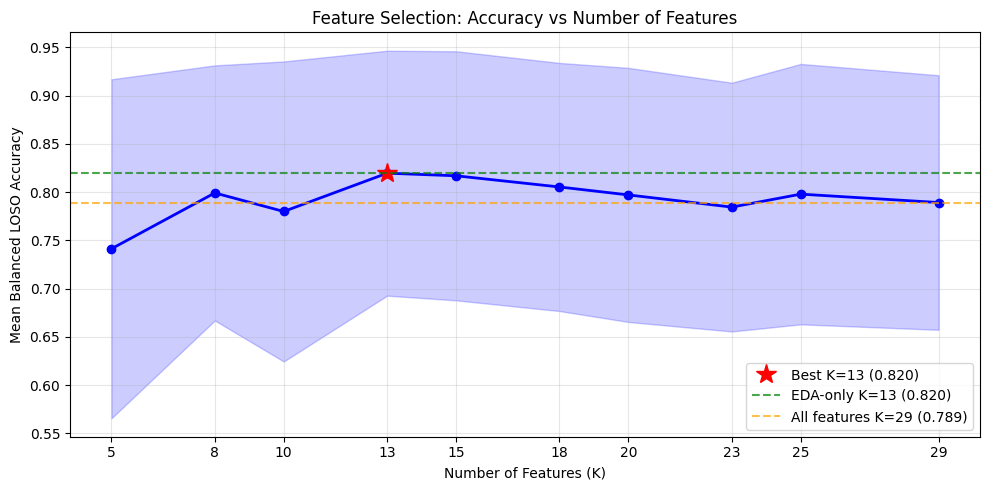

In [20]:
# visualize

# extracts the parallels
k_vals = list(k_results.keys())
means = [k_results[k]['mean'] for k in k_vals]
stds = [k_results[k]['std'] for k in k_vals]

plt.figure(figsize=(10,5))
plt.plot(k_vals, means, 'b-o', linewidth=2, markersize=6)
plt.fill_between(
    k_vals,
    [m - s for m, s in zip(means, stds)],
    [m + s for m, s in zip(means, stds)],
    alpha=0.2, color='blue'
)

# one red start at the best K value
best_mean = k_results[best_k]['mean']
plt.plot(best_k, best_mean, 'r*', markersize=15,
         label=f'Best K={best_k} ({best_mean:.3f})')
plt.axhline(
    y=k_results[13]['mean'], color='green',
    linestyle='--', alpha=0.7,
    label=f'EDA-only K=13 ({k_results[13]["mean"]:.3f})'
)
plt.axhline(
    y=k_results[29]['mean'], color = 'orange',
    linestyle='--', alpha=0.7,
    label=f'All features K=29 ({k_results[29]["mean"]:.3f})'
)

plt.xlabel('Number of Features (K)')
plt.ylabel('Mean Balanced LOSO Accuracy')
plt.title('Feature Selection: Accuracy vs Number of Features')
plt.legend()
plt.xticks(k_vals)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# find the features most consistently selected

# gets a list and counts each value up
feature_names_list = list(feature_df.columns)
selection_counts = Counter()
total_folds = len(np.unique(groups_all))

for train_idx, test_idx in logo.split(
    X_unscaled, y_all, groups=groups_all
):
    X_train = X_unscaled[train_idx]
    y_train = y_all[train_idx]

    selector = SelectKBest(f_classif, k=best_k)
    selector.fit(X_train, y_train)

    # gets list of length 29 (True at any selected position)
    selected_mask = selector.get_support()

    # converts the boolean mask into feature names
    selected_features = [
        feature_names_list[i]
    for i, selected in enumerate(selected_mask)
    if selected
    ]
    selection_counts.update(selected_features)

print(f"Feature selection frequency across {total_folds} folds")
print(f"Best K={best_k}, max possible selections = {total_folds}")
print(f"\n{'Feature':<30} {'Count':>8} {'Freq':>8} Bar")
print("-" * 60)

for feature, count in sorted(
    selection_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    freq = count / total_folds
    bar = "-" * int(freq*20)
    modality = (
        'EDA' if any(x in feature for x in
                    ['tonic', 'phasic', 'scr']) else
        'HRV' if any(x in feature for x in
                    ['hr', 'hrv']) else
        'ACC'
    )
    print(f"{feature:<30} {count:>5}/{total_folds}"
          f" {freq:>6.1%} {bar} [{modality}]")

Feature selection frequency across 15 folds
Best K=13, max possible selections = 15

Feature                           Count     Freq Bar
------------------------------------------------------------
tonic_mean                        15/15 100.0% -------------------- [EDA]
tonic_std                         15/15 100.0% -------------------- [EDA]
tonic_min                         15/15 100.0% -------------------- [EDA]
tonic_max                         15/15 100.0% -------------------- [EDA]
tonic_slope                       15/15 100.0% -------------------- [EDA]
tonic_range                       15/15 100.0% -------------------- [EDA]
phasic_std                        15/15 100.0% -------------------- [EDA]
phasic_min                        15/15 100.0% -------------------- [EDA]
phasic_max                        15/15 100.0% -------------------- [EDA]
phasic_range                      15/15 100.0% -------------------- [EDA]
scr_count                         15/15 100.0% --------------

In [22]:
# Summary!
print("-" * 60)
print("FEATURE SELECTION SUMMARY")
print("-" * 60)

print(f"\nBaseline (EDA only, K=13):     "
      f"{k_results[13]['mean']:.3f} balanced accuracy")
print(f"All features (multimodal, K=29): "
      f"{k_results[29]['mean']:.3f} balanced accuracy")
print(f"Optimal K={best_k}:               "
      f"{k_results[best_k]['mean']:.3f} balanced accuracy")

improvement_over_all = (
    k_results[best_k]['mean'] - k_results[29]['mean']
)
improvement_over_eda = (
    k_results[best_k]['mean'] - k_results[13]['mean']
)

print(f"\nImprovement over all-features: "
      f"{improvement_over_all:+.3f}")
print(f"Improvement over EDA-only:     "
      f"{improvement_over_eda:+.3f}")

print("\n--- Interpretation ---")

if improvement_over_all > 0.02:
    print("Feature selection meaningfully improved over "
          "using all features.")
    print("Some multimodal features were adding noise.")
elif improvement_over_all < -0.02:
    print("All features performed better than any subset.")
    print("Each modality contributes independent signal.")
else:
    print("Feature selection made little difference.")
    print("Most features carry roughly equal information.")

if improvement_over_eda > 0.02:
    print("\nMultimodal features improved over EDA alone.")
    print("HRV and/or ACC features contribute real signal.")
elif improvement_over_eda < -0.02:
    print("\nEDA alone outperformed multimodal features.")
    print("Additional modalities added more noise than signal")
    print("for WESAD stress classification specifically.")
    print("Note: this may differ for naturalistic distraction.")
else:
    print("\nMultimodal and EDA-only performed similarly.")
    print("EDA captures most available information at 4 Hz.")

# Most consistently selected features
print("\n--- Most consistently selected features ---")
top_features = sorted(
    selection_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]  # top 5

for i, (feature, count) in enumerate(top_features):
    modality = (
        'EDA' if any(x in feature for x in 
                     ['tonic', 'phasic', 'scr']) else
        'HRV' if any(x in feature for x in 
                     ['hr', 'hrv']) else
        'ACC'
    )
    print(f"  {i+1}. {feature} ({modality}) -- "
          f"selected in {count}/{total_folds} folds")

------------------------------------------------------------
FEATURE SELECTION SUMMARY
------------------------------------------------------------

Baseline (EDA only, K=13):     0.820 balanced accuracy
All features (multimodal, K=29): 0.789 balanced accuracy
Optimal K=13:               0.820 balanced accuracy

Improvement over all-features: +0.030
Improvement over EDA-only:     +0.000

--- Interpretation ---
Feature selection meaningfully improved over using all features.
Some multimodal features were adding noise.

Multimodal and EDA-only performed similarly.
EDA captures most available information at 4 Hz.

--- Most consistently selected features ---
  1. tonic_mean (EDA) -- selected in 15/15 folds
  2. tonic_std (EDA) -- selected in 15/15 folds
  3. tonic_min (EDA) -- selected in 15/15 folds
  4. tonic_max (EDA) -- selected in 15/15 folds
  5. tonic_slope (EDA) -- selected in 15/15 folds
